# Lab 2: PMV, PPD and operative temperature (ISO 7730)

**Goal.** Compute the thermal-comfort indices for the summer day (outdoor air), then find indoor conditions with $-0.5 < PMV < 0.5$.

| Symbol | Meaning | Unit |
|---|---|---|
| $t_a$ | air temperature | °C |
| $t_{mr}$ | mean radiant temperature (average temperature of the surrounding surfaces) | °C |
| $v$ | relative air speed | m/s |
| $RH$ | relative humidity | % |
| $I_{clo}$ | clothing insulation (1 clo = 0.155 m²·K/W) | clo |
| $M_{met}$ | metabolic rate (1 met = 58.15 W/m², a person sitting at rest) | met |
| $PMV$ | Predicted Mean Vote, scale −3 (cold) … 0 (neutral) … +3 (hot) | – |
| $PPD$ | Predicted Percentage Dissatisfied | % |
| $t_o$ | operative temperature | °C |

All heat flows are per m² of body surface (W/m²).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from calculate_pmv_ppd import calculate_pmv_ppd, operative_temperature

## Step 2: unit conversions

- $M = M_{met}\cdot 58.15$ [W/m²]: metabolic heat produced per m² of skin.
- $I_{cl} = 0.155\cdot I_{clo}$ [m²·K/W]: thermal resistance of the clothes.
- $p_{sat}(t_a) = e^{16.6536-\frac{4030.183}{t_a+235}}$ [kPa] (Antoine equation): the maximum water-vapour pressure air can hold at $t_a$.
- $p_v = \frac{RH}{100}\cdot p_{sat}\cdot 1000$ [Pa]: the actual vapour pressure. Humid air ($p_v$ high) slows sweat evaporation, so you feel warmer.
- $f_{cl}=1+1.29\,I_{cl}$ if $I_{cl}<0.078$, else $1.05+0.645\,I_{cl}$ [–]: clothed area / nude area. Clothes enlarge the surface that exchanges heat.

In [2]:
t_a, t_mr, v, rh, i_clo, m_met = 30, 30.5, 0.15, 60, 0.5, 1.2   # summer day, outdoor air

M     = m_met * 58.15                                   # W/m2
I_cl  = 0.155 * i_clo                                   # m2.K/W
p_sat = np.exp(16.6536 - 4030.183 / (t_a + 235)) * 1000 # Pa
p_v   = rh / 100 * p_sat                                # Pa
f_cl  = 1 + 1.29 * I_cl if I_cl < 0.078 else 1.05 + 0.645 * I_cl
print(f"M={M:.2f} W/m2  I_cl={I_cl:.4f} m2K/W  p_sat={p_sat:.0f} Pa  p_v={p_v:.0f} Pa  f_cl={f_cl:.3f}")

M=69.78 W/m2  I_cl=0.0775 m2K/W  p_sat=4243 Pa  p_v=2546 Pa  f_cl=1.100


## Step 3: clothing surface temperature $t_{cl}$ (iteration)

The clothes pass heat from the skin (≈ 35.7 °C minus a term for the work done by the body) to the room. In steady state:

$$t_{cl} = 35.7 - 0.028\,M - I_{cl}\,(RL_5 + RL_6)$$

but $RL_5$ and $RL_6$ themselves depend on $t_{cl}$, so we guess, recompute and repeat (ISO 7730 scheme, working with $x=T_{cl}/100$ in K/100). We stop when the old and new $x$ differ by less than $\epsilon = 0.0015$, i.e. 0.15 K. Averaging old and new value keeps the iteration stable. Kelvin conversion uses 273.15.

Convection coefficient [W/(m²·K)]: $h_c=\max(h_{c,f},h_{c,n})$ with forced $h_{c,f}=12.1\sqrt v$ (driven by air speed) and natural $h_{c,n}=2.38\,|t_{cl}-t_a|^{0.25}$ (driven by the temperature difference).

## Step 4: the six heat-loss paths [W/m²]

| Path | Formula | Physical meaning |
|---|---|---|
| $RL_1$ | $3.05\cdot10^{-3}(5733-6.99M-p_v)$ | vapour diffusing through the skin |
| $RL_2$ | $0.42(M-58.15)$, only if $M>58.15$ | regulatory sweating |
| $RL_3$ | $1.7\cdot10^{-5}M(5867-p_v)$ | latent heat of breathing (moisture exhaled) |
| $RL_4$ | $0.0014\,M(34-t_a)$ | dry heat of breathing (warming inhaled air) |
| $RL_5$ | $3.96 f_{cl}[(T_{cl}/100)^4-(T_{mr}/100)^4]$ | radiation clothes → room surfaces (temps in **K**) |
| $RL_6$ | $f_{cl}\,h_c\,(t_{cl}-t_a)$ | convection clothes → room air |

## Step 5: PMV and PPD

$$TS = 0.303\,e^{-0.036M}+0.028 \;[\mathrm{m^2/W}],\qquad L = M-\sum_{i=1}^{6}RL_i \;[\mathrm{W/m^2}],\qquad PMV = TS\cdot L$$

$L>0$: the body produces more heat than it loses, so it feels warm (PMV > 0). $L<0$: it feels cold.

$$PPD = 100-95\,e^{-0.03353\,PMV^4-0.2179\,PMV^2}\;[\%]$$

PPD never drops below 5 %: even at PMV = 0 some people are unhappy.

## Step 6: operative temperature

$t_o = A\,t_a+(1-A)\,t_{mr}$ with $A=0.5$ for $v<0.2$ m/s, $0.6$ for $0.2\le v<0.6$, $0.7$ for $v\ge0.6$. More air movement gives air temperature more weight.

## Part 1: outdoor summer day

In [3]:
pmv, ppd, t_o, n = calculate_pmv_ppd(t_a, t_mr, v=v, rh=rh, i_clo=i_clo, m_met=m_met)
print(f"PMV= {pmv:.3f}", f"PPD= {ppd:.1f} %", f"t_o= {t_o:.2f} degC", f"n iterations= {n}", sep=chr(10))

PMV= 1.767
PPD= 65.3 %
t_o= 30.25 degC
n iterations= 8


PMV ≈ 1.7 means "warm to hot" and about 62 % of people are dissatisfied.

> **Check against the sheet.** The lab sheet gives PMV = 1.767, PPD = 65.3 %, $t_o$ = 30.25 °C, $n$ = 8. The code reproduces all four.

## Part 2: indoor conditions with $-0.5<PMV<0.5$

Same $RH$, $v$, clothing and activity. Only $t_a$ and $t_{mr}$ change. Sweep $t_a$ with $t_{mr}=t_a+0.5$ °C.

-0.5 < PMV < 0.5 for t_a from 23.25 to 26.0 degC (t_mr = t_a + 0.5)


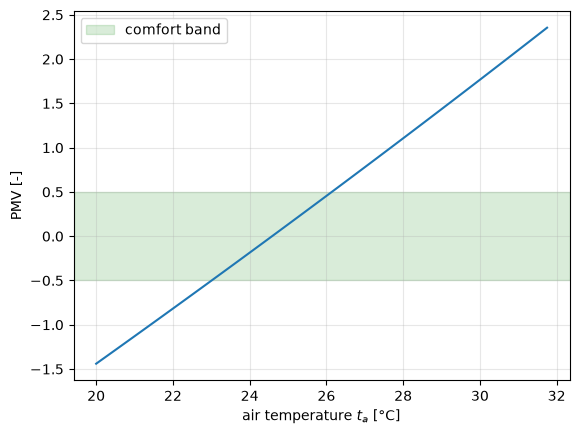

In [4]:
ta_range = np.arange(20, 32, 0.25)
pmv_curve = np.array([calculate_pmv_ppd(t, t + 0.5)[0] for t in ta_range])
ok = ta_range[np.abs(pmv_curve) < 0.5]
print(f"-0.5 < PMV < 0.5 for t_a from {ok.min()} to {ok.max()} degC (t_mr = t_a + 0.5)")

plt.plot(ta_range, pmv_curve)
plt.axhspan(-0.5, 0.5, color="green", alpha=0.15, label="comfort band")
plt.xlabel("air temperature $t_a$ [°C]"); plt.ylabel("PMV [-]"); plt.legend(); plt.grid(alpha=.3)
plt.show()

In [5]:
t_a_in, t_mr_in = 24.5, 25          # chosen: PMV close to 0, t_mr = t_a + 0.5
pmv, ppd, t_o, n = calculate_pmv_ppd(t_a_in, t_mr_in, v=0.15, rh=60, i_clo=0.5, m_met=1.2)
print(f"t_a={t_a_in}  t_mr={t_mr_in}", f"PMV= {pmv:.3f}", f"PPD= {ppd:.1f} %", f"t_o= {t_o:.2f} degC", f"n iterations= {n}", sep=chr(10))

t_a=24.5  t_mr=25
PMV= -0.027
PPD= 5.0 %
t_o= 24.75 degC
n iterations= 8


**Answer.** $t_a = 24.5$ °C, $t_{mr}=25$ °C gives PMV ≈ −0.03 and PPD ≈ 5 %, practically neutral. Any $t_a$ from about 23.25 to 26 °C (with $t_{mr}=t_a+0.5$) stays inside the ±0.5 band. The outdoor air (30 °C) is about 5 °C too hot, which is why cooling is needed in summer.